In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim
import torch.nn.functional as F
import os
from glob import glob
import rasterio

In [2]:
# Set device to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

print(torch.cuda.is_available())  # True = CUDA GPU is ready
print(torch.cuda.device_count())  # Number of available GPUs
print(torch.cuda.get_device_name(0))  # Name of first GPU

# Check available CUDA memory
torch.cuda.empty_cache()
free_mem = torch.cuda.mem_get_info()[0] / (1024 ** 3)  # in GB
total_mem = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)  # in GB
print(f"CUDA Free memory: {free_mem:.2f} GB / {total_mem:.2f} GB")

Using device: cuda
True
1
NVIDIA GeForce RTX 3090 Ti
CUDA Free memory: 22.48 GB / 23.99 GB


# DATASET FOR BINARY MASKS

In [3]:
# Path to your folder (update this path to match your local system)
folder_path = r"D:\RUbel Ahmmed 0421162025\Data\Harirampur Padma\ALL Water Polygon"
# Get all .tif files in the folder
LS_NIR = sorted(glob(os.path.join(folder_path, '*.tif')))
print(f"Found {len(LS_NIR)} GeoTIFF images.")
# # Check the number of bands for each .tif file
# for tif in LS_NIR:
#     with rasterio.open(tif) as src:
#         print(f"{os.path.basename(tif)} - Number of bands: {src.count}")
#         print(f"Width: {src.width}, Height: {src.height}")
# # =================== Visualization of first 38 images ===================
# plt.figure(figsize=(30, 20))
# for i, tif in enumerate(LS_NIR[:38]):  # Display first 6 images
#     with rasterio.open(tif) as src:
#         band1 = src.read(1)
#     plt.subplot(5, 8, i+1)
#     plt.imshow(band1, cmap='gray')
#     # Display split upto  2nd _ filename as title
#     plt.title(os.path.basename(tif).split('_')[0:2])
#     plt.axis('off')
# plt.tight_layout()
# plt.show()

# =================== Load images into a time-series array ===================
LS_NIR_List = []
crs = None
transform = None
for i, tif in enumerate(LS_NIR):
    with rasterio.open(tif) as src:
        img = src.read(1).astype(np.float32)  # Read all 3 bands
        # img = np.moveaxis(img, 0, -1)  # Reorder the dimensions (from [bands, height, width] to [height, width, bands])
        LS_NIR_List.append(img)
        if i == 0:
            crs = src.crs
            transform = src.transform
# Stack into time-series array: shape [time, height, width, bands]
LS_NIR_Seq = np.stack(LS_NIR_List).astype(np.float32)
print("Image sequence shape:", LS_NIR_Seq.shape)
print("CRS:", crs)
print("Transform:", transform)

data = torch.tensor(LS_NIR_Seq)  # [time, channels, height, width]
print("Data tensor shape:", data.shape)

def create_dataset(data, input_seq_len, target_seq_len):
    inputs = []
    targets = []
    total_seq_len = input_seq_len + target_seq_len
    for i in range(len(data) - total_seq_len + 1):
        input_seq = data[i:i+input_seq_len]
        target_seq = data[i+input_seq_len:i+total_seq_len]
        inputs.append(input_seq)
        targets.append(target_seq)
    return torch.stack(inputs), torch.stack(targets)

input_seq_len = 5
target_seq_len = 1
inputs, targets = create_dataset(data, input_seq_len, target_seq_len)
inputs = inputs  # Add channel dimension
print("Inputs shape:", inputs.shape)
print("Targets shape:", targets.shape)

x_train = inputs[:32]
y_train = targets[:32]
x_val = inputs[32:]
y_val = targets[32:]
x_test = inputs[32:]
y_test = targets[32:]
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_val shape:", x_val.shape)
print("y_val shape:", y_val.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

# ==================== Create DataLoader ====================
train_dataset = TensorDataset(x_train, y_train)
test_dataset = TensorDataset(x_test, y_test)
val_dataset = TensorDataset(x_test, y_test)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=4, shuffle=False)
val_loader = torch.utils.data.DataLoader(test_dataset, batch_size=4, shuffle=False)


Found 38 GeoTIFF images.
Image sequence shape: (38, 755, 945)
CRS: EPSG:32645
Transform: | 30.00, 0.00, 785220.00|
| 0.00,-30.00, 2630850.00|
| 0.00, 0.00, 1.00|
Data tensor shape: torch.Size([38, 755, 945])
Inputs shape: torch.Size([33, 5, 755, 945])
Targets shape: torch.Size([33, 1, 755, 945])
x_train shape: torch.Size([32, 5, 755, 945])
y_train shape: torch.Size([32, 1, 755, 945])
x_val shape: torch.Size([1, 5, 755, 945])
y_val shape: torch.Size([1, 1, 755, 945])
x_test shape: torch.Size([1, 5, 755, 945])
y_test shape: torch.Size([1, 1, 755, 945])


# Generator

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import os
from datetime import datetime
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ==================== MODELS ====================
# ==================== FIXED GENERATOR ====================
class Generator(nn.Module):
    """Generator that works with any input size"""
    def __init__(self, in_channels=5, out_channels=1):
        super().__init__()
        
        # Encoder
        self.enc1 = nn.Sequential(
            nn.Conv2d(in_channels, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        
        self.enc2 = nn.Sequential(
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )
        
        self.enc3 = nn.Sequential(
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )
        
        self.enc4 = nn.Sequential(
            nn.MaxPool2d(2),
            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True)
        )
        
        # Bridge
        self.bridge = nn.Sequential(
            nn.MaxPool2d(2),
            nn.Conv2d(512, 1024, 3, padding=1),
            nn.BatchNorm2d(1024),
            nn.ReLU(inplace=True),
            nn.Conv2d(1024, 1024, 3, padding=1),
            nn.BatchNorm2d(1024),
            nn.ReLU(inplace=True)
        )
        
        # Decoder
        self.upconv4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = nn.Sequential(
            nn.Conv2d(1024, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True)
        )
        
        self.upconv3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = nn.Sequential(
            nn.Conv2d(512, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )
        
        self.upconv2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = nn.Sequential(
            nn.Conv2d(256, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )
        
        self.upconv1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = nn.Sequential(
            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        
        # Final
        self.final = nn.Conv2d(64, out_channels, 1)
        
    def forward(self, x):
        # Store original size
        orig_h, orig_w = x.shape[2], x.shape[3]
        
        # Encoder
        e1 = self.enc1(x)  # (64, H, W)
        e2 = self.enc2(e1)  # (128, H/2, W/2)
        e3 = self.enc3(e2)  # (256, H/4, W/4)
        e4 = self.enc4(e3)  # (512, H/8, W/8)
        
        # Bridge
        b = self.bridge(e4)  # (1024, H/16, W/16)
        
        # Decoder with adaptive resizing for skip connections
        d4 = self.upconv4(b)  # (512, H/8, W/8)
        # Resize e4 to match d4 if needed
        if e4.shape[2:] != d4.shape[2:]:
            e4_resized = F.interpolate(e4, size=d4.shape[2:], mode='bilinear', align_corners=False)
        else:
            e4_resized = e4
        d4 = torch.cat([d4, e4_resized], dim=1)
        d4 = self.dec4(d4)
        
        d3 = self.upconv3(d4)  # (256, H/4, W/4)
        if e3.shape[2:] != d3.shape[2:]:
            e3_resized = F.interpolate(e3, size=d3.shape[2:], mode='bilinear', align_corners=False)
        else:
            e3_resized = e3
        d3 = torch.cat([d3, e3_resized], dim=1)
        d3 = self.dec3(d3)
        
        d2 = self.upconv2(d3)  # (128, H/2, W/2)
        if e2.shape[2:] != d2.shape[2:]:
            e2_resized = F.interpolate(e2, size=d2.shape[2:], mode='bilinear', align_corners=False)
        else:
            e2_resized = e2
        d2 = torch.cat([d2, e2_resized], dim=1)
        d2 = self.dec2(d2)
        
        d1 = self.upconv1(d2)  # (64, H, W)
        if e1.shape[2:] != d1.shape[2:]:
            e1_resized = F.interpolate(e1, size=d1.shape[2:], mode='bilinear', align_corners=False)
        else:
            e1_resized = e1
        d1 = torch.cat([d1, e1_resized], dim=1)
        d1 = self.dec1(d1)
        
        # Final output
        output = self.final(d1)
        
        # Ensure output matches original size
        if output.shape[2:] != (orig_h, orig_w):
            output = F.interpolate(output, size=(orig_h, orig_w), 
                                 mode='bilinear', align_corners=False)
        
        return torch.sigmoid(output)
    
# Check model output shape
gen = Generator(in_channels=5, out_channels=1).to(device)
output = gen(x_test[:1].to(device))
print("Output shape:", output.shape)
print("Input shape:", x_test[:1].shape)

# Generator paarameter count
total_params = sum(p.numel() for p in gen.parameters())
print(f"Total parameters in Generator: {total_params}")

Using device: cuda
Output shape: torch.Size([1, 1, 755, 945])
Input shape: torch.Size([1, 5, 755, 945])
Total parameters in Generator: 31044673


In [5]:
class Discriminator(nn.Module):
    def __init__(self, in_channels=6):  # 5 condition + 1 image
        super().__init__()
        
        self.model = nn.Sequential(
            # Input: (6, 755, 945)
            nn.Conv2d(in_channels, 64, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(256, 512, 4, 2, 1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            
            # PatchGAN output
            nn.Conv2d(512, 1, 4, 1, 1),
        )
    
    def forward(self, condition, image):
        x = torch.cat([condition, image], dim=1)
        return self.model(x)  # (batch, 1, 46, 59)

# Check Discriminator output shape
disc = Discriminator(in_channels=6).to(device)
# disc_out = disc(x_test[:1].to(device), y_test[:1].to(device))
# print("Discriminator real output shape:", disc_out.shape)
# disc_facke = disc(x_test[:1].to(device), pred_test)
# print("Discriminator fake output shape:", disc_facke.shape)

# total parameters in Discriminator
total_params_disc = sum(p.numel() for p in disc.parameters())
print(f"Total parameters in Discriminator: {total_params_disc}")


Total parameters in Discriminator: 2769601


# METRICS 

In [37]:
# ==================== METRICS ====================
def compute_iou(pred, target, threshold=0.5):
    """Compute Intersection over Union"""
    pred_bin = (pred > threshold).float()
    target_bin = (target > threshold).float()
    
    intersection = (pred_bin * target_bin).sum(dim=(1, 2, 3))
    union = pred_bin.sum(dim=(1, 2, 3)) + target_bin.sum(dim=(1, 2, 3)) - intersection
    iou = (intersection + 1e-6) / (union + 1e-6)
    return iou.mean().item()

def compute_dice(pred, target, threshold=0.5):
    """Compute Dice coefficient"""
    pred_bin = (pred > threshold).float()
    target_bin = (target > threshold).float()
    
    intersection = (pred_bin * target_bin).sum(dim=(1, 2, 3))
    dice = (2. * intersection + 1e-6) / (pred_bin.sum(dim=(1, 2, 3)) + target_bin.sum(dim=(1, 2, 3)) + 1e-6)
    return dice.mean().item()

# Check the Matrices and output dim

In [39]:
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=4, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1, shuffle=False)

for x_train, y_train in train_loader:
    pred_batch = gen(x_train.to(device))
    print("x_train Shape :", x_train.shape)
    print("Predicted Shape :", pred_batch.shape)
    print("Actual y_train Shape :", y_train.shape)
    real_disc = disc(x_train.to(device), y_train.to(device))
    print("Discriminator real output shape in training loop:", real_disc.shape)
    fack_disc = disc(x_train.to(device), pred_batch)
    print("Discriminator fake output shape in training loop:", fack_disc.shape)

    # Compute metrics
    iou = compute_iou(pred_batch.cpu(), y_train)
    dice = compute_dice(pred_batch.cpu(), y_train)
    print(f"IOU: {iou:.4f}, Dice: {dice:.4f}")

x_train Shape : torch.Size([4, 5, 755, 945])
Predicted Shape : torch.Size([4, 1, 755, 945])
Actual y_train Shape : torch.Size([4, 1, 755, 945])
Discriminator real output shape in training loop: torch.Size([4, 1, 46, 58])
Discriminator fake output shape in training loop: torch.Size([4, 1, 46, 58])
IOU: 0.2575, Dice: 0.4052
x_train Shape : torch.Size([4, 5, 755, 945])
Predicted Shape : torch.Size([4, 1, 755, 945])
Actual y_train Shape : torch.Size([4, 1, 755, 945])
Discriminator real output shape in training loop: torch.Size([4, 1, 46, 58])
Discriminator fake output shape in training loop: torch.Size([4, 1, 46, 58])
IOU: 0.2007, Dice: 0.3342
x_train Shape : torch.Size([4, 5, 755, 945])
Predicted Shape : torch.Size([4, 1, 755, 945])
Actual y_train Shape : torch.Size([4, 1, 755, 945])
Discriminator real output shape in training loop: torch.Size([4, 1, 46, 58])
Discriminator fake output shape in training loop: torch.Size([4, 1, 46, 58])
IOU: 0.2116, Dice: 0.3473
x_train Shape : torch.Size([

In [ ]:
# ==================== LOSS FUNCTIONS ====================
class CombinedLoss(nn.Module):
    def __init__(self, bce_weight=1.0, dice_weight=1.0, iou_weight=1.0, pos_weight=2.0):
        super().__init__()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.iou_weight = iou_weight
        self.pos_weight = pos_weight
        
    def bce_loss(self, predictions, targets):
        bce = F.binary_cross_entropy_with_logits(
            predictions, targets, reduction='none', pos_weight=torch.tensor(self.pos_weight)
        )
        return bce.mean()
    
    def dice_loss(self, predictions, targets, smooth=1e-6):
        # Apply sigmoid to predictions
        predictions = torch.sigmoid(predictions)
        
        # Flatten predictions and targets
        predictions_flat = predictions.view(-1)
        targets_flat = targets.view(-1)
        
        intersection = (predictions_flat * targets_flat).sum()
        dice = (2. * intersection + smooth) / (predictions_flat.sum() + targets_flat.sum() + smooth)
        
        return 1 - dice
    
    def iou_loss(self, predictions, targets, smooth=1e-6):
        # Apply sigmoid to predictions
        predictions = torch.sigmoid(predictions)
        
        # Flatten predictions and targets
        predictions_flat = predictions.view(-1)
        targets_flat = targets.view(-1)
        
        intersection = (predictions_flat * targets_flat).sum()
        union = predictions_flat.sum() + targets_flat.sum() - intersection
        
        iou = (intersection + smooth) / (union + smooth)
        
        return 1 - iou
    
    def forward(self, predictions, targets):
        # Calculate individual losses
        bce_loss = self.bce_loss(predictions, targets)
        dice_loss = self.dice_loss(predictions, targets)
        iou_loss = self.iou_loss(predictions, targets)
        
        # Combine losses with weights
        total_loss = (
            self.bce_weight * bce_loss + 
            self.dice_weight * dice_loss + 
            self.iou_weight * iou_loss
        )
        
        # Return total loss and individual losses for logging
        loss_dict = {
            'total_loss': total_loss.item(),
            'bce_loss': bce_loss.item(),
            'dice_loss': dice_loss.item(),
            'iou_loss': iou_loss.item()
        }
        
        return total_loss, loss_dict
    
# Sample usage:
criterion = CombinedLoss(bce_weight=1.0, dice_weight=1.0, iou_weight=1.0, pos_weight=2.0)

for x_batch, y_batch in train_loader:
    y_pred = model(x_batch)
    loss, loss_details = criterion(y_pred, y_batch)
    print("Training Loss:", loss.item())
    print("Loss Details:", loss_details)
    break  


# Evaluate and Plot

In [103]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support
import pandas as pd


def evaluate_model(model, test_loader, device='cpu'):
    """Comprehensive evaluation of river prediction model"""
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            preds = (outputs > 0.5).float()
            all_preds.append(preds.cpu())
            all_targets.append(targets.cpu())
    
    all_preds = torch.cat(all_preds, dim=0)
    all_targets = torch.cat(all_targets, dim=0)
    
    return all_preds, all_targets

def calculate_river_metrics(y_true, y_pred):
    """Calculate river-specific metrics"""
    y_true_np = y_true.cpu().numpy().flatten()
    y_pred_np = y_pred.cpu().numpy().flatten()
    
    # Basic classification metrics
    cm = confusion_matrix(y_true_np, y_pred_np)
    tn, fp, fn, tp = cm.ravel()
    
    # River-specific metrics
    total_pixels = y_true_np.size
    water_pixels_true = np.sum(y_true_np == 1)
    water_pixels_pred = np.sum(y_pred_np == 1)
    
    # Hydrological metrics
    iou_water = tp / (tp + fp + fn + 1e-10)
    iou_land = tn / (tn + fp + fn + 1e-10)
    
    # Connectivity metrics (approximate)
    from scipy import ndimage
    pred_water = y_pred[0, 0].cpu().numpy() if y_pred.dim() > 2 else y_pred.cpu().numpy()
    true_water = y_true[0, 0].cpu().numpy() if y_true.dim() > 2 else y_true.cpu().numpy()
    
    # Number of connected water bodies
    labeled_pred, num_features_pred = ndimage.label(pred_water > 0.5)
    labeled_true, num_features_true = ndimage.label(true_water > 0.5)
    
    metrics = {
        'accuracy': (tp + tn) / (tp + tn + fp + fn),
        'precision_water': tp / (tp + fp + 1e-10),
        'recall_water': tp / (tp + fn + 1e-10),
        'f1_water': 2 * tp / (2 * tp + fp + fn + 1e-10),
        'iou_water': iou_water,
        'iou_land': iou_land,
        'water_pixels_true': water_pixels_true,
        'water_pixels_pred': water_pixels_pred,
        'water_area_ratio_true': water_pixels_true / total_pixels,
        'water_area_ratio_pred': water_pixels_pred / total_pixels,
        'num_water_bodies_true': num_features_true,
        'num_water_bodies_pred': num_features_pred,
        'false_positive_rate': fp / (fp + tn + 1e-10),
        'false_negative_rate': fn / (fn + tp + 1e-10),
    }
    
    return metrics, cm

def generate_detailed_report(metrics, model_name="Conv3D River Predictor"):
    """Generate detailed evaluation report"""
    report = f"""
    {'='*60}
    RIVER PLANFORM PREDICTION EVALUATION REPORT
    {'='*60}
    Model: {model_name}
    Timestamp: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
    
    {'-'*60}
    CLASSIFICATION METRICS:
    {'-'*60}
    Accuracy:           {metrics['accuracy']:.4f}
    Precision (Water):  {metrics['precision_water']:.4f}
    Recall (Water):     {metrics['recall_water']:.4f}
    F1-Score (Water):   {metrics['f1_water']:.4f}
    
    {'-'*60}
    SEGMENTATION METRICS:
    {'-'*60}
    IoU (Water):        {metrics['iou_water']:.4f}
    IoU (Land):         {metrics['iou_land']:.4f}
    False Positive Rate: {metrics['false_positive_rate']:.4f}
    False Negative Rate: {metrics['false_negative_rate']:.4f}
    
    {'-'*60}
    RIVER MORPHOLOGY:
    {'-'*60}
    Water Pixels (True):  {metrics['water_pixels_true']:,}
    Water Pixels (Pred):  {metrics['water_pixels_pred']:,}
    Water Area Ratio:     {metrics['water_area_ratio_true']:.4f}
    Water Bodies (True):  {metrics['num_water_bodies_true']}
    Water Bodies (Pred):  {metrics['num_water_bodies_pred']}
    
    {'='*60}
    """
    print(report)
    

# ====== MAIN EVALUATION PIPELINE ======
if __name__ == "__main__":
    # Load your trained model
    model = Generator()  # Your model class
    # CORRECT WAY:
    checkpoint = torch.load(r'D:\RUbel Ahmmed 0421162025\pytorch_venv\Final Model\Model_05_Padma_Gan\checkpoints\best_model.pth')
    model.load_state_dict(checkpoint['generator_state_dict'])
    model.eval()
    
    # Move to device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    
    # 1. Evaluate on test data
    print("Evaluating model on test data...")
    y_pred, y_true = evaluate_model(model, test_loader, device)
    
    # 2. Calculate metrics
    metrics, cm = calculate_river_metrics(y_true, y_pred)
    
    # 3. Generate report
    generate_detailed_report(metrics)
    
    
    

Evaluating model on test data...

    RIVER PLANFORM PREDICTION EVALUATION REPORT
    Model: Conv3D River Predictor
    Timestamp: 2026-01-30 14:14:11

    ------------------------------------------------------------
    CLASSIFICATION METRICS:
    ------------------------------------------------------------
    Accuracy:           0.9405
    Precision (Water):  0.8076
    Recall (Water):     0.9236
    F1-Score (Water):   0.8617

    ------------------------------------------------------------
    SEGMENTATION METRICS:
    ------------------------------------------------------------
    IoU (Water):        0.7571
    IoU (Land):         0.9270
    False Positive Rate: 0.0552
    False Negative Rate: 0.0764

    ------------------------------------------------------------
    RIVER MORPHOLOGY:
    ------------------------------------------------------------
    Water Pixels (True):  143,162
    Water Pixels (Pred):  163,716
    Water Area Ratio:     0.2007
    Water Bodies (True):  125

# Traing History Plot

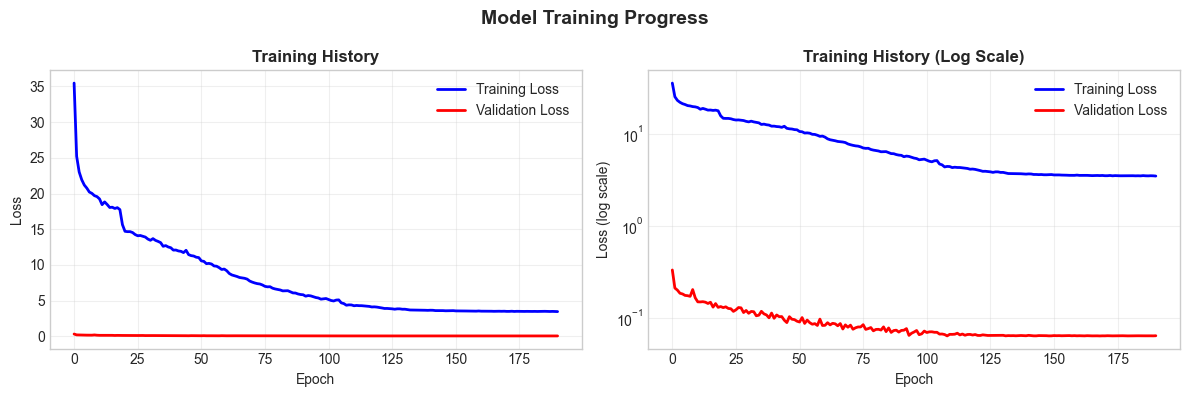

In [104]:
def plot_training_history(loss_history, val_loss_history, save_path=None):
    """Plot training and validation loss history"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Loss curves
    ax1.plot(loss_history, label='Training Loss', linewidth=2, color='blue')
    ax1.plot(val_loss_history, label='Validation Loss', linewidth=2, color='red')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training History', fontsize=12, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Log scale for better visualization
    ax2.semilogy(loss_history, label='Training Loss', linewidth=2, color='blue')
    ax2.semilogy(val_loss_history, label='Validation Loss', linewidth=2, color='red')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss (log scale)')
    ax2.set_title('Training History (Log Scale)', fontsize=12, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.suptitle('Model Training Progress', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
train_history_path = r'D:\RUbel Ahmmed 0421162025\pytorch_venv\Final Model\Model_05_Padma_Gan\final_model.pth'
history_data = torch.load(train_history_path)['history']
plot_training_history(history_data['train_g_loss'], history_data['val_loss'], save_path=None)
                        

# Actual vs Prediction Plot

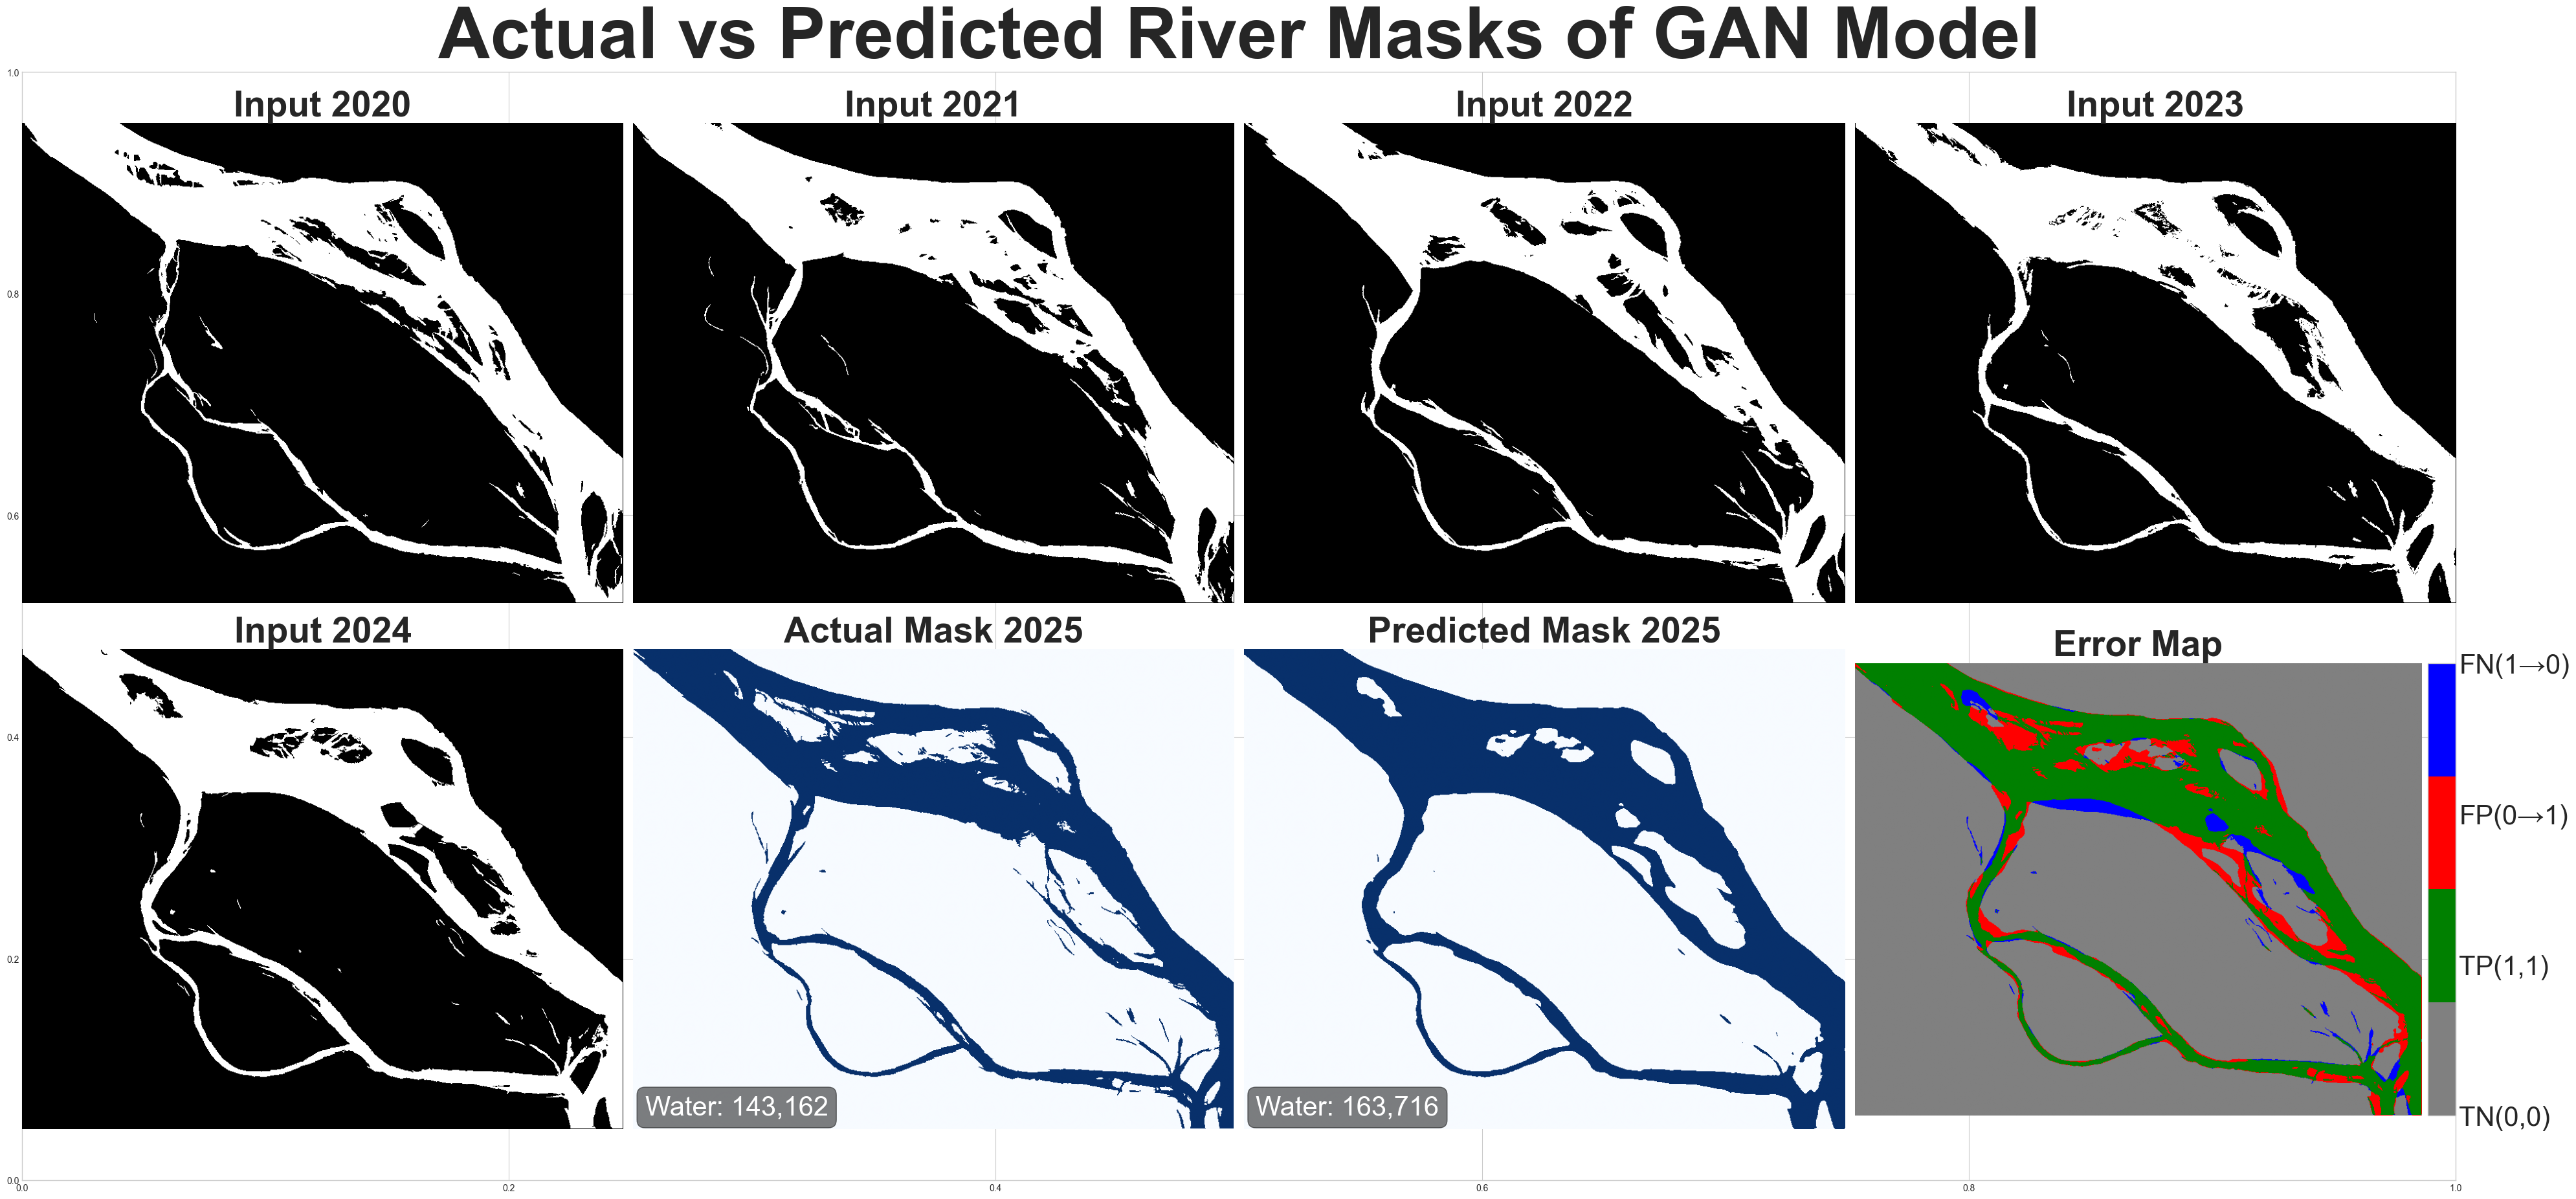

In [105]:
def visualize_evaluation(y_test, y_pred, x_test, sample_idx=0, save_path=None):
    """Enhanced visualization with metrics - assuming x_test has shape [batch, seq_len, 1, H, W]"""
    # Ensure tensors
    if isinstance(y_test, np.ndarray):
        y_test = torch.from_numpy(y_test)
    if isinstance(x_test, np.ndarray):
        y_pred = torch.from_numpy(y_pred)
    
    # Ensure binary
    y_test_bin = y_test.int()
    x_test_bin = x_test.int()
    y_pred_bin = (y_pred > 0.5).int()
    
    # Classification map
    result = torch.zeros_like(y_test_bin, dtype=torch.int8)
    result[(y_test_bin == 1) & (y_pred_bin == 1)] = 1     # True Positive
    result[(y_test_bin == 0) & (y_pred_bin == 1)] = 2     # False Positive
    result[(y_test_bin == 1) & (y_pred_bin == 0)] = 3     # False Negative
    
    # Colors and labels
    cmap = ListedColormap(['gray', 'green', 'red', 'blue'])
    labels = ['TN(0,0)', 'TP(1,1)', 'FP(0→1)', 'FN(1→0)']
    
    # Calculate metrics
    metrics, cm = calculate_river_metrics(y_test_bin, y_pred_bin)
    
    # Create figure with 2×4 grid
    fig = plt.figure(figsize=(40, 20))
    
    # Assuming x_test shape: [batch, sequence_len=5, 1, H, W]
    time_labels = ['2020', '2021', '2022', '2023', '2024']
    plt.title('Actual vs Predicted River Masks of GAN Model', fontsize=80, fontweight='bold')
    # Plot all 5 input frames (columns 1-5)
    for i in range(5):
        ax = plt.subplot(2, 4, i+1)
        
        # Get the i-th frame in the sequence
        if x_test.dim() == 5:  # [batch, seq_len, channels, H, W]
            img_to_show = x_test[sample_idx, i, 0].cpu().numpy()
        elif x_test.dim() == 4:  # [batch, seq_len*channels, H, W]
            img_to_show = x_test[sample_idx, i].cpu().numpy()
        else:
            img_to_show = x_test[sample_idx].cpu().numpy()
        
        ax.imshow(img_to_show, cmap='gray')
        ax.set_title(f'Input {time_labels[i]}', fontsize=40, fontweight='bold')
        ax.axis('off')
    
    # 6: Actual River Mask (t)
    ax6 = plt.subplot(2, 4, 6)
    actual_mask = y_test[sample_idx, 0].cpu().numpy() if y_test.dim() > 2 else y_test.cpu().numpy()
    ax6.imshow(actual_mask, cmap='Blues', vmin=0, vmax=1)
    ax6.set_title('Actual Mask 2025', fontsize=40, fontweight='bold')
    ax6.axis('off')
    ax6.text(0.02, 0.02, f'Water: {metrics["water_pixels_true"]:,}', 
             transform=ax6.transAxes, color='white', fontsize=30,
             verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='black', alpha=0.5))
    
    # 7: Predicted River Mask (t)
    ax7 = plt.subplot(2, 4, 7)
    pred_mask = y_pred[sample_idx, 0].cpu().numpy() if y_pred.dim() > 2 else y_pred.cpu().numpy()
    ax7.imshow(pred_mask, cmap='Blues', vmin=0, vmax=1)
    ax7.set_title('Predicted Mask 2025', fontsize=40, fontweight='bold')
    ax7.axis('off')
    ax7.text(0.02, 0.02, f'Water: {metrics["water_pixels_pred"]:,}', 
             transform=ax7.transAxes, color='white', fontsize=30,
             verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='black', alpha=0.5))
    
    # 8: Error Classification
    ax8 = plt.subplot(2, 4, 8)
    error_map = result[sample_idx, 0].cpu().numpy() if result.dim() > 2 else result.cpu().numpy()
    im = ax8.imshow(error_map, cmap=cmap, vmin=0, vmax=3)
    ax8.set_title('Error Map', fontsize=40, fontweight='bold')
    ax8.axis('off')
    
    # Add colorbar for error map
    divider = make_axes_locatable(ax8)
    cax = divider.append_axes("right", size="5%", pad=0.1)
    cbar = plt.colorbar(im, cax=cax, ticks=[0, 1, 2, 3])
    cbar.ax.set_yticklabels(labels, fontsize=30)
   
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.1)
    
    if save_path:
        plt.savefig(save_path, dpi=100, bbox_inches='tight')
        print(f"Saved to {save_path}")
    
    plt.show()
visualize_evaluation(y_test, y_pred, x_test, sample_idx=0, save_path=None)

# Evaluation Matrix plot

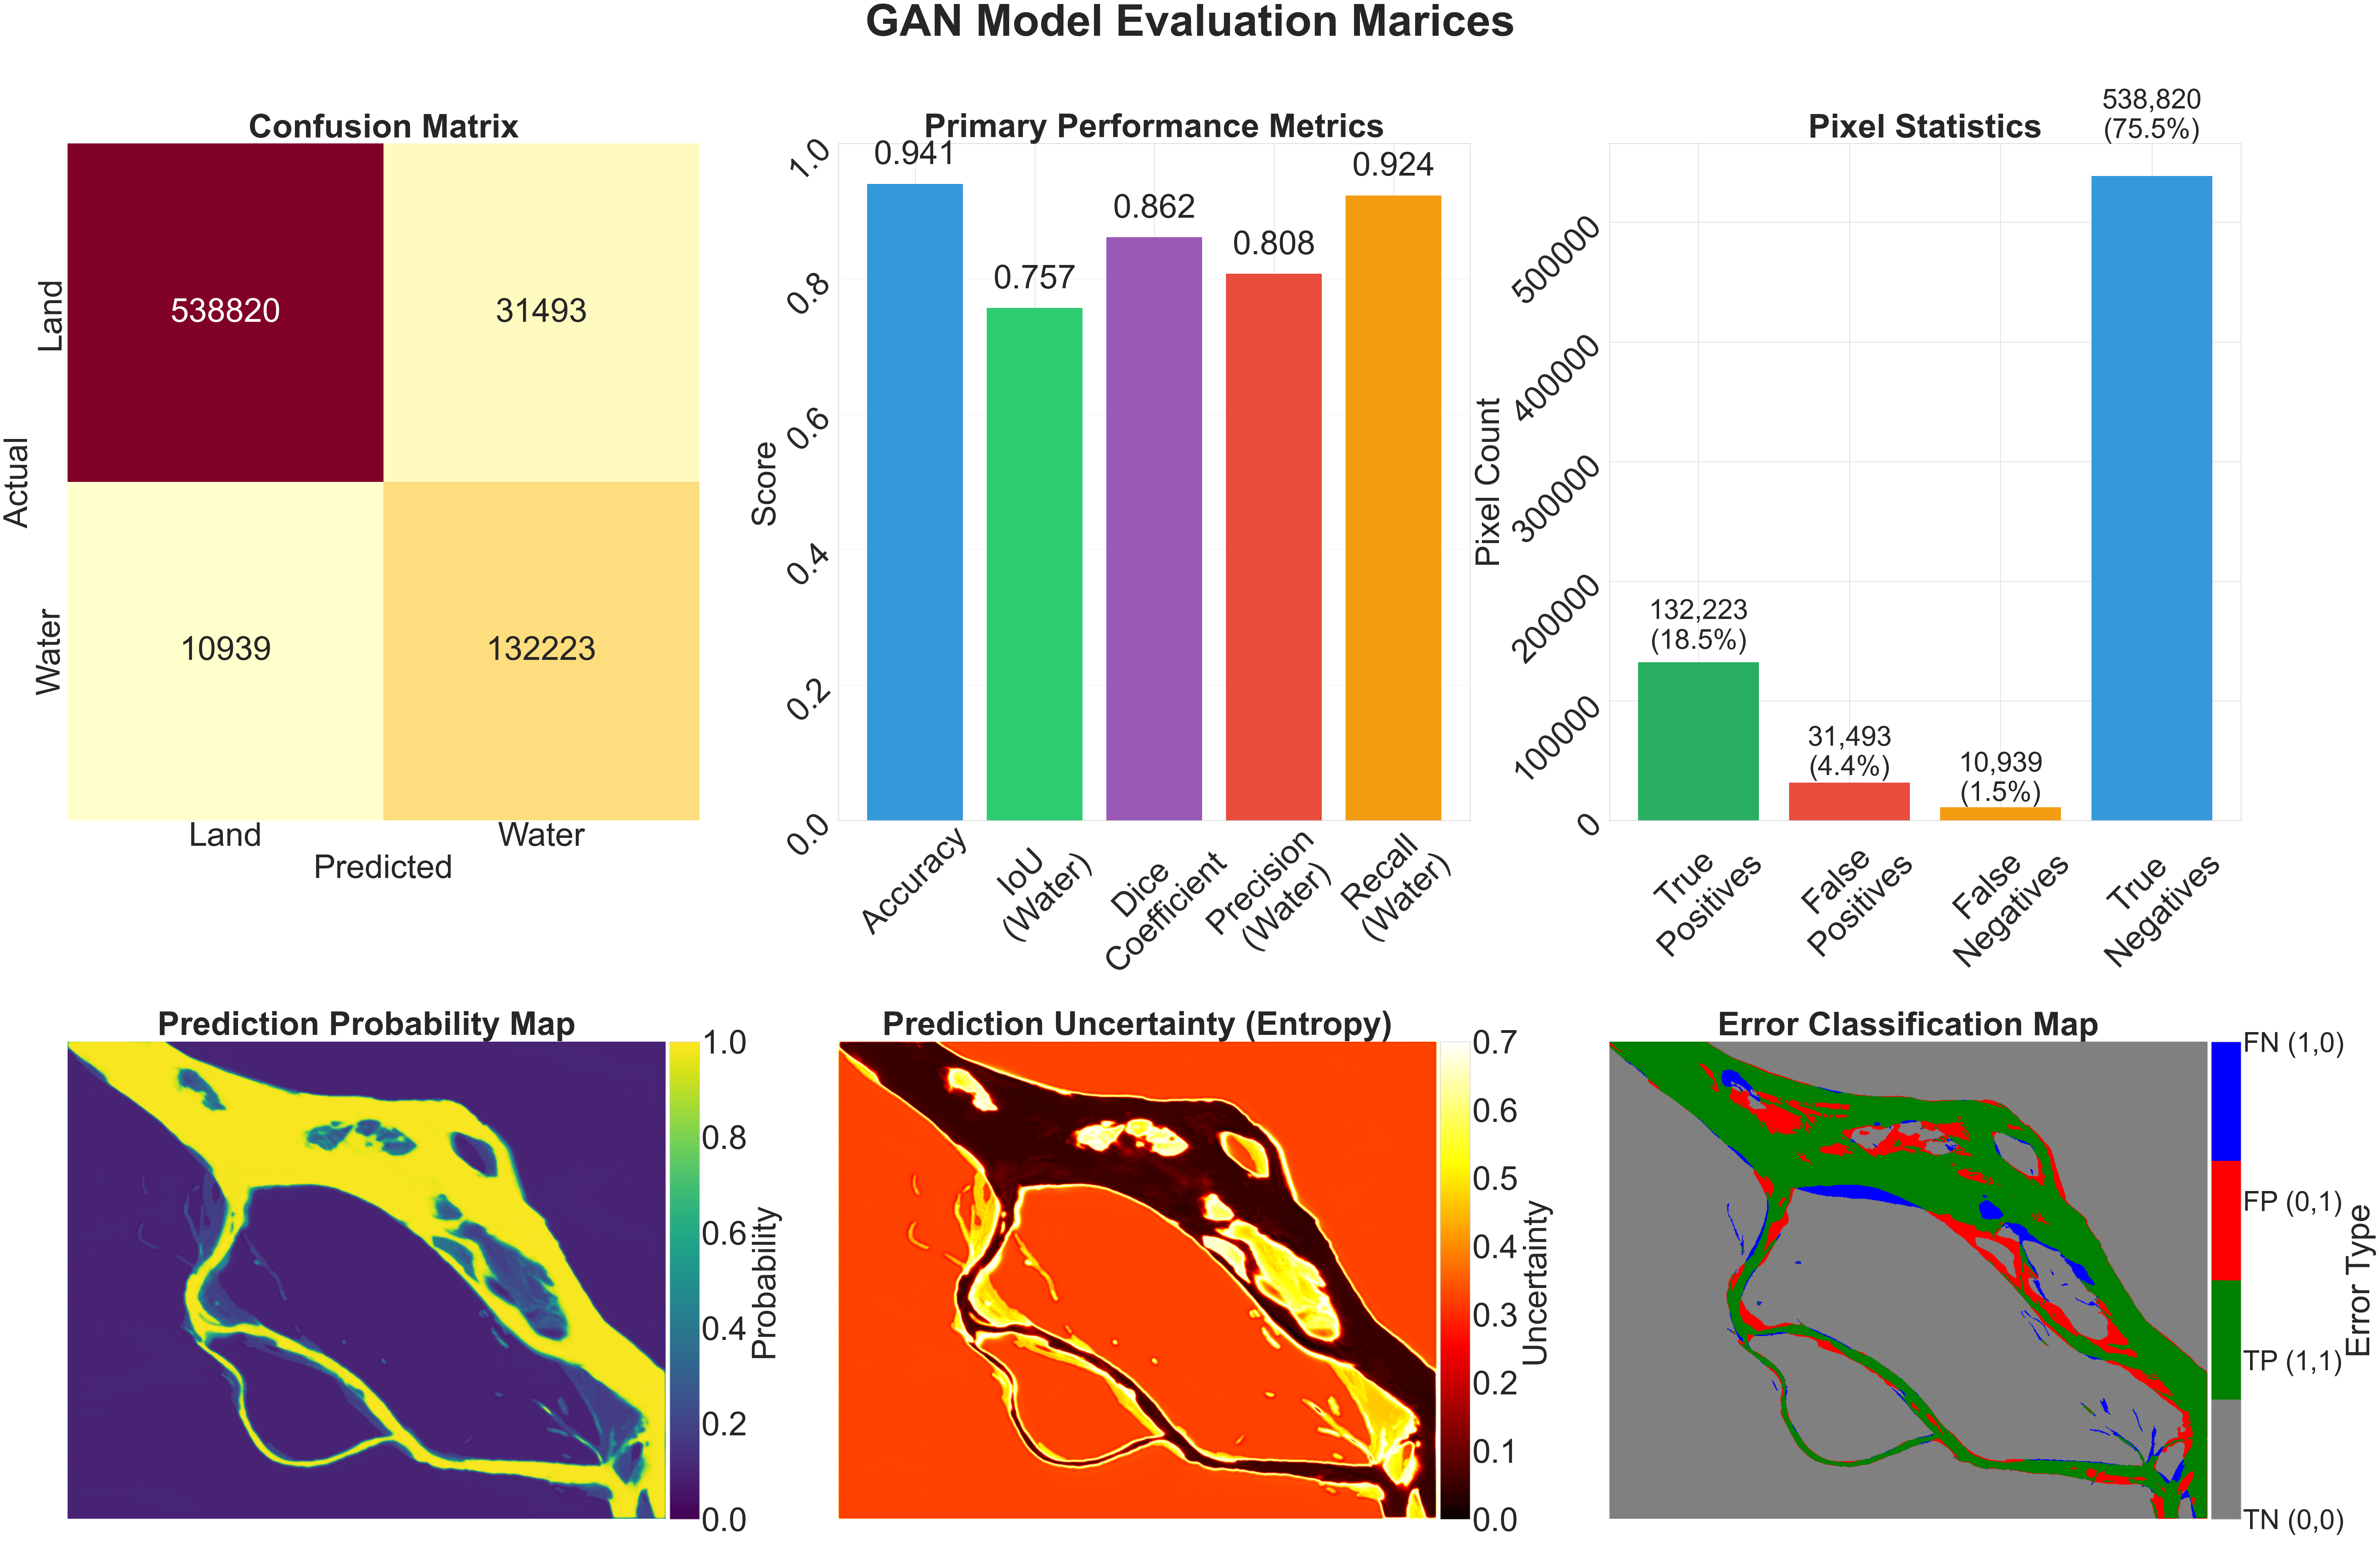

In [106]:
def Matricesplot(y_test, y_pred, model=None, x_test=None, device='cpu', sample_idx=0, save_path=None):
    """Enhanced visualization with metrics including probability and uncertainty maps"""
    # Ensure tensors
    if isinstance(y_test, np.ndarray):
        y_test = torch.from_numpy(y_test)
    if isinstance(y_pred, np.ndarray):
        y_pred = torch.from_numpy(y_pred)
    
    # Ensure binary
    y_test_bin = y_test.int()
    y_pred_bin = (y_pred > 0.5).int()
    
    # Calculate metrics
    metrics, cm = calculate_river_metrics(y_test_bin, y_pred_bin)
    
    # Get probability map if model and x_test are provided
    prob_map = None
    if model is not None and x_test is not None:
        with torch.no_grad():
            model.eval()
            if isinstance(x_test, np.ndarray):
                x_test = torch.from_numpy(x_test)
            x_test = x_test.to(device)
            predictions = model(x_test)
            
            if predictions.dim() > 2:
                prob_map = predictions[sample_idx, 0].cpu().numpy() if predictions.shape[1] == 1 else predictions[sample_idx].cpu().numpy()
            else:
                prob_map = predictions.cpu().numpy()
    
    # Create figure with 3x2 grid (6 plots total)
    fig = plt.figure(figsize=(60, 40))
    
    # 1. Confusion Matrix Heatmap
    ax1 = plt.subplot(2, 3, 1)
    heatmap = sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
                          annot_kws={"size": 60},
                          xticklabels=['Land', 'Water'], 
                          yticklabels=['Land', 'Water'],
                          ax=ax1,
                          cbar=False)
    ax1.set_title('Confusion Matrix', fontsize=60, fontweight='bold')
    ax1.set_xlabel('Predicted', fontsize=60)
    ax1.set_ylabel('Actual', fontsize=60)
    ax1.tick_params(axis='both', labelsize=60)
    
    # 2. Primary Metrics
    ax2 = plt.subplot(2, 3, 2)
    primary_metrics = ['Accuracy', 'IoU\n(Water)', 'Dice\nCoefficient', 'Precision\n(Water)', 'Recall\n(Water)']
    primary_values = [
        metrics['accuracy'],
        metrics['iou_water'],
        metrics.get('dice_water', metrics.get('f1_water', 0)),
        metrics['precision_water'],
        metrics['recall_water']
    ]
    
    colors1 = ['#3498db', '#2ecc71', '#9b59b6', '#e74c3c', '#f39c12']
    bars1 = ax2.bar(primary_metrics, primary_values, color=colors1)
    ax2.set_ylim([0, 1])
    ax2.set_title('Primary Performance Metrics', fontsize=60, fontweight='bold')
    ax2.set_ylabel('Score', fontsize=60)
    ax2.tick_params(axis='both', labelsize=60, rotation=45)
    ax2.grid(True, alpha=0.3, axis='y')
    
    for bar, val in zip(bars1, primary_values):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=60)
    
    # 3. Pixel Statistics
    ax3 = plt.subplot(2, 3, 3)
    
    # Calculate pixel statistics
    total_pixels = cm.sum()
    tp, fp, fn, tn = cm[1, 1], cm[0, 1], cm[1, 0], cm[0, 0]
    
    stats_labels = ['True\nPositives', 'False\nPositives', 'False\nNegatives', 'True\nNegatives']
    stats_values = [tp, fp, fn, tn]
    stats_percentages = [tp/total_pixels*100, fp/total_pixels*100, 
                         fn/total_pixels*100, tn/total_pixels*100]
    
    colors3 = ['#27ae60', '#e74c3c', '#f39c12', '#3498db']
    bars3 = ax3.bar(stats_labels, stats_values, color=colors3)
    ax3.set_title('Pixel Statistics', fontsize=60, fontweight='bold')
    ax3.set_ylabel('Pixel Count', fontsize=60)
    ax3.tick_params(axis='both', labelsize=60, rotation=45)
    
    # Add both count and percentage
    for bar, val, pct in zip(bars3, stats_values, stats_percentages):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + height*0.05,
                f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=50)
    
    # 4. Probability Map (if available)
    ax4 = plt.subplot(2, 3, 4)
    if prob_map is not None:
        im1 = ax4.imshow(prob_map, cmap='viridis', vmin=0, vmax=1)
        ax4.set_title('Prediction Probability Map', fontsize=60, fontweight='bold')
        ax4.axis('off')
        divider1 = make_axes_locatable(ax4)
        cax1 = divider1.append_axes("right", size="5%", pad=0.1)
        cbar1 = plt.colorbar(im1, cax=cax1)
        cbar1.ax.tick_params(labelsize=60)
        cbar1.set_label('Probability', fontsize=60)
    else:
        # If no probability map, show actual mask
        if y_test.dim() > 2:
            actual_mask = y_test[sample_idx, 0].cpu().numpy() if y_test.shape[1] == 1 else y_test[sample_idx].cpu().numpy()
        else:
            actual_mask = y_test.cpu().numpy()
        
        im1 = ax4.imshow(actual_mask, cmap='Blues', vmin=0, vmax=1)
        ax4.set_title('Actual Water Mask', fontsize=60, fontweight='bold')
        ax4.axis('off')
        divider1 = make_axes_locatable(ax4)
        cax1 = divider1.append_axes("right", size="5%", pad=0.1)
        cbar1 = plt.colorbar(im1, cax=cax1, ticks=[0, 1])
        cbar1.ax.set_yticklabels(['Land', 'Water'], fontsize=60)
        cbar1.set_label('Class', fontsize=60)
    
    # 5. Uncertainty Map (if probability map is available)
    ax5 = plt.subplot(2, 3, 5)
    if prob_map is not None:
        # Calculate entropy as uncertainty measure
        prob_map_clipped = np.clip(prob_map, 1e-10, 1 - 1e-10)  # Avoid log(0)
        uncertainty = -prob_map_clipped * np.log(prob_map_clipped) - (1 - prob_map_clipped) * np.log(1 - prob_map_clipped)
        
        im2 = ax5.imshow(uncertainty, cmap='hot', vmin=0, vmax=0.7)
        ax5.set_title('Prediction Uncertainty (Entropy)', fontsize=60, fontweight='bold')
        ax5.axis('off')
        divider2 = make_axes_locatable(ax5)
        cax2 = divider2.append_axes("right", size="5%", pad=0.1)
        cbar2 = plt.colorbar(im2, cax=cax2)
        cbar2.ax.tick_params(labelsize=60)
        cbar2.set_label('Uncertainty', fontsize=60)
    else:
        # If no uncertainty map, show predicted mask
        if y_pred.dim() > 2:
            pred_mask = y_pred[sample_idx, 0].cpu().numpy() if y_pred.shape[1] == 1 else y_pred[sample_idx].cpu().numpy()
        else:
            pred_mask = y_pred.cpu().numpy()
        
        im2 = ax5.imshow(pred_mask, cmap='Blues', vmin=0, vmax=1)
        ax5.set_title('Predicted Water Mask', fontsize=60, fontweight='bold')
        ax5.axis('off')
        divider2 = make_axes_locatable(ax5)
        cax2 = divider2.append_axes("right", size="5%", pad=0.1)
        cbar2 = plt.colorbar(im2, cax=cax2, ticks=[0, 1])
        cbar2.ax.set_yticklabels(['Land', 'Water'], fontsize=60)
        cbar2.set_label('Class', fontsize=60)
    
    # 6. Error Classification Map
    ax6 = plt.subplot(2, 3, 6)
    
    # Get actual and predicted masks
    if y_test.dim() > 2:
        actual_mask = y_test[sample_idx, 0].cpu().numpy() if y_test.shape[1] == 1 else y_test[sample_idx].cpu().numpy()
    else:
        actual_mask = y_test.cpu().numpy()
    
    if y_pred.dim() > 2:
        pred_mask = y_pred[sample_idx, 0].cpu().numpy() if y_pred.shape[1] == 1 else y_pred[sample_idx].cpu().numpy()
    else:
        pred_mask = y_pred.cpu().numpy()
    
    # Create error map
    pred_mask_bin = (pred_mask > 0.5).astype(np.int32)
    error_map = np.zeros_like(actual_mask, dtype=np.int32)
    error_map[(actual_mask == 0) & (pred_mask_bin == 0)] = 0  # TN
    error_map[(actual_mask == 1) & (pred_mask_bin == 1)] = 1  # TP
    error_map[(actual_mask == 0) & (pred_mask_bin == 1)] = 2  # FP
    error_map[(actual_mask == 1) & (pred_mask_bin == 0)] = 3  # FN
    
    cmap_error = ListedColormap(['gray', 'green', 'red', 'blue'])
    im3 = ax6.imshow(error_map, cmap=cmap_error, vmin=0, vmax=3)
    ax6.set_title('Error Classification Map', fontsize=60, fontweight='bold')
    ax6.axis('off')
    divider3 = make_axes_locatable(ax6)
    cax3 = divider3.append_axes("right", size="5%", pad=0.1)
    cbar3 = plt.colorbar(im3, cax=cax3, ticks=[0, 1, 2, 3])
    cbar3.ax.set_yticklabels(['TN (0,0)', 'TP (1,1)', 'FP (0,1)', 'FN (1,0)'], fontsize=50)
    cbar3.set_label('Error Type', fontsize=60)
    
    plt.suptitle('GAN Model Evaluation Marices', fontsize=80, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    # if save_path:
    #     plt.savefig(save_path, dpi=100, bbox_inches='tight')
    #     print(f"Metrics visualization saved to {save_path}")
    
    plt.show()
    
Matricesplot(y_test, y_pred, model=model, x_test=x_test, device=device)